Introduction

Cardiovascular diseases are one of the leading causes of death worldwide. Early detection of heart disease risk can help medical professionals provide treatment earlier and improve survival rates.

This report explores the Heart Failure Prediction Dataset, which contains patient clinical data used to predict whether a patient has heart disease.

The objectives of this analysis are:

Understand the dataset and its features
Explore relationships between variables
Investigate how features affect heart disease prediction
Detect missing values and outliers
Perform bivariate and multivariate analysis
Suggest feature engineering improvements

The dataset contains 918 patient records and 12 features including demographic data, medical measurements, and exercise test results.

The target variable is:

HeartDisease

1 = patient has heart disease
0 = patient does not have heart disease

Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Load the Dataset

In [4]:
df = pd.read_csv("heart.csv")

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Check dataset structure.

In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Feature Description

| Feature        | Description                       |
| -------------- | --------------------------------- |
| Age            | Age of the patient                |
| Sex            | Gender (M/F)                      |
| ChestPainType  | Type of chest pain                |
| RestingBP      | Resting blood pressure            |
| Cholesterol    | Serum cholesterol                 |
| FastingBS      | Fasting blood sugar >120 mg/dl    |
| RestingECG     | Resting electrocardiogram results |
| MaxHR          | Maximum heart rate achieved       |
| ExerciseAngina | Exercise-induced angina           |
| Oldpeak        | ST depression during exercise     |
| ST_Slope       | Slope of peak exercise ST segment |
| HeartDisease   | Target variable                   |


Summary Statistics

In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Observations:

Age ranges roughly between 28 and 77 years.

Cholesterol and blood pressure values vary widely.

Some values such as cholesterol = 0 may indicate missing or incorrect measurements.

Checking Missing Values

In [7]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Observation:

No missing values appear in the dataset.

However, we should also check for invalid values such as zero cholesterol.

In [8]:
(df["Cholesterol"] == 0).sum()

np.int64(172)

Target Variable Distribution

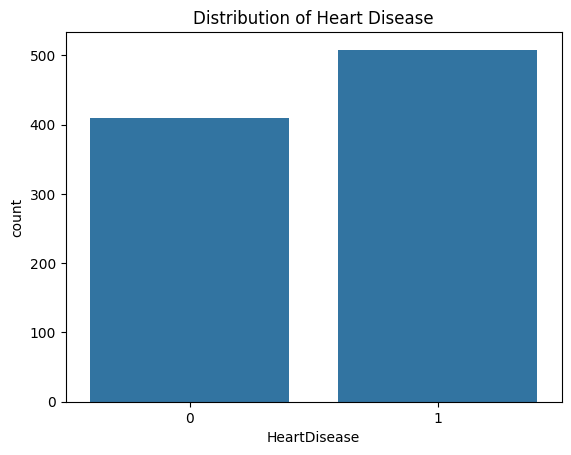

In [9]:
sns.countplot(x="HeartDisease", data=df)

plt.title("Distribution of Heart Disease")
plt.show()

Observation:

The dataset shows a slightly higher number of patients with heart disease than without.

This means the dataset is somewhat imbalanced, which may influence machine learning models.

Univariate Analysis

Age Distribution

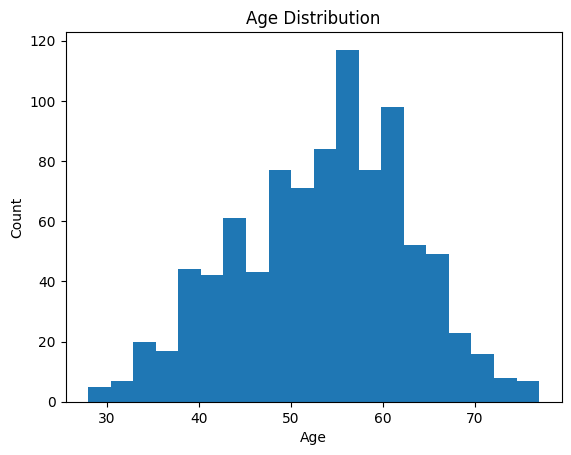

In [10]:
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Observation:

Most patients fall between 40–65 years old.

Cholesterol Distribution

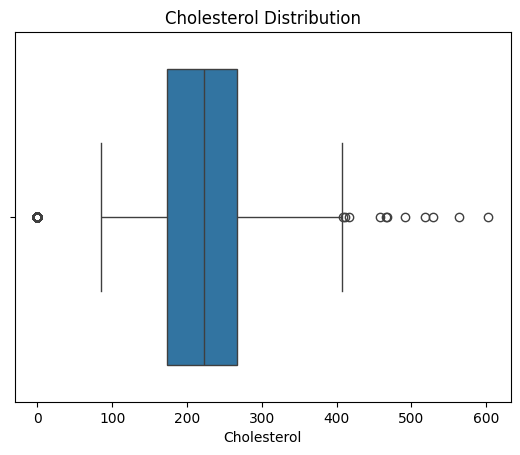

In [11]:
sns.boxplot(x=df["Cholesterol"])
plt.title("Cholesterol Distribution")
plt.show()

Observation:

Some extreme cholesterol values exist which may represent outliers.

Feature Effect on Target Variable

Age vs Heart Disease

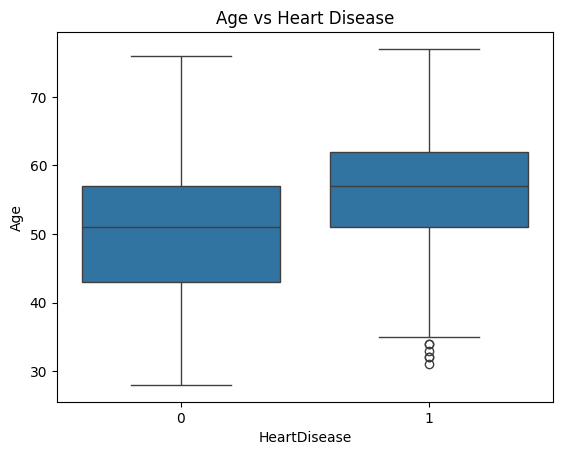

In [12]:
sns.boxplot(x="HeartDisease", y="Age", data=df)

plt.title("Age vs Heart Disease")
plt.show()

Observation:

Patients with heart disease tend to be older.

Sex vs Heart Disease

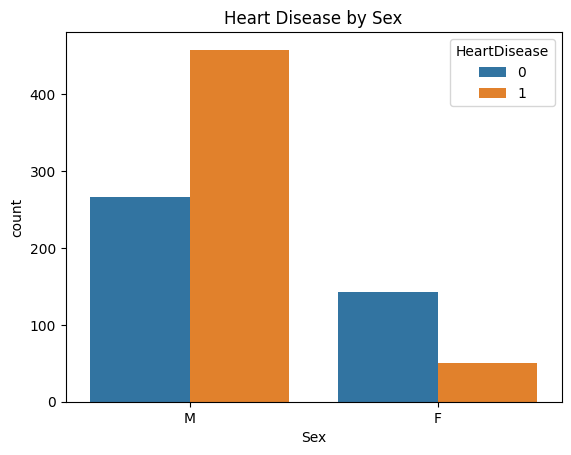

In [13]:
sns.countplot(x="Sex", hue="HeartDisease", data=df)

plt.title("Heart Disease by Sex")
plt.show()

Observation:

Male patients appear to have higher incidence of heart disease.

Chest Pain Type

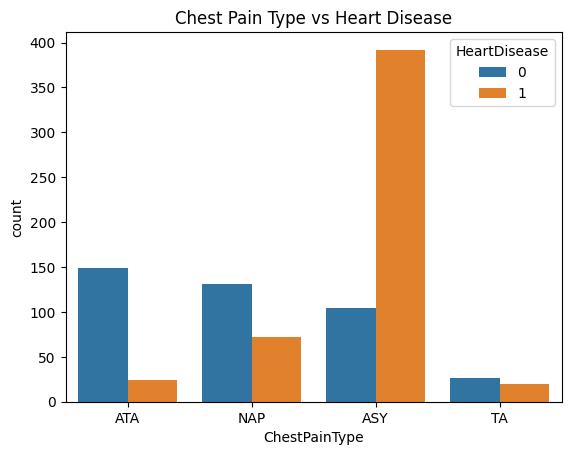

In [14]:
sns.countplot(x="ChestPainType", hue="HeartDisease", data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.show()

Observation:

Certain chest pain categories show stronger associations with heart disease.

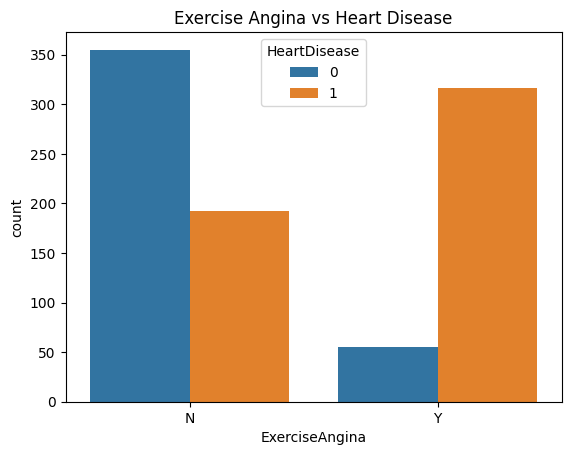

In [15]:
sns.countplot(x="ExerciseAngina", hue="HeartDisease", data=df)

plt.title("Exercise Angina vs Heart Disease")
plt.show()

Observation:

Exercise-induced angina is more common among patients with heart disease.

Correlation Analysis

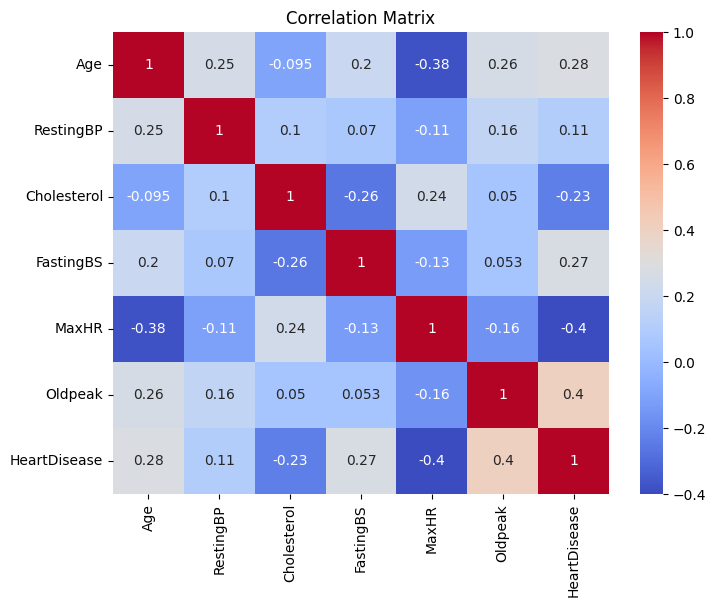

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

Observations:

Oldpeak has positive correlation with heart disease.
MaxHR often shows negative correlation.

Interpretation:

Higher ST depression (Oldpeak) indicates higher risk of heart disease.
Higher maximum heart rate during exercise is often associated with healthier patients.

Outlier Detection

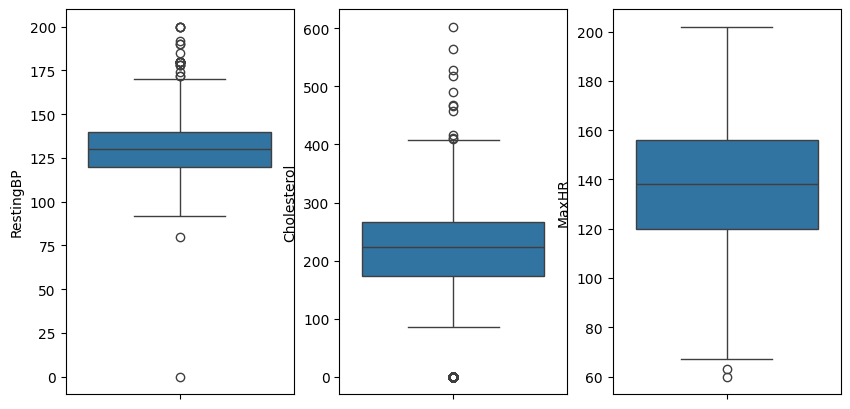

In [17]:
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
sns.boxplot(y=df["RestingBP"])

plt.subplot(1,3,2)
sns.boxplot(y=df["Cholesterol"])

plt.subplot(1,3,3)
sns.boxplot(y=df["MaxHR"])

plt.show()

Observations:

Some extreme values are visible.

These may influence model performance.

Bivariate / Multivariate Analysis

Pairplot

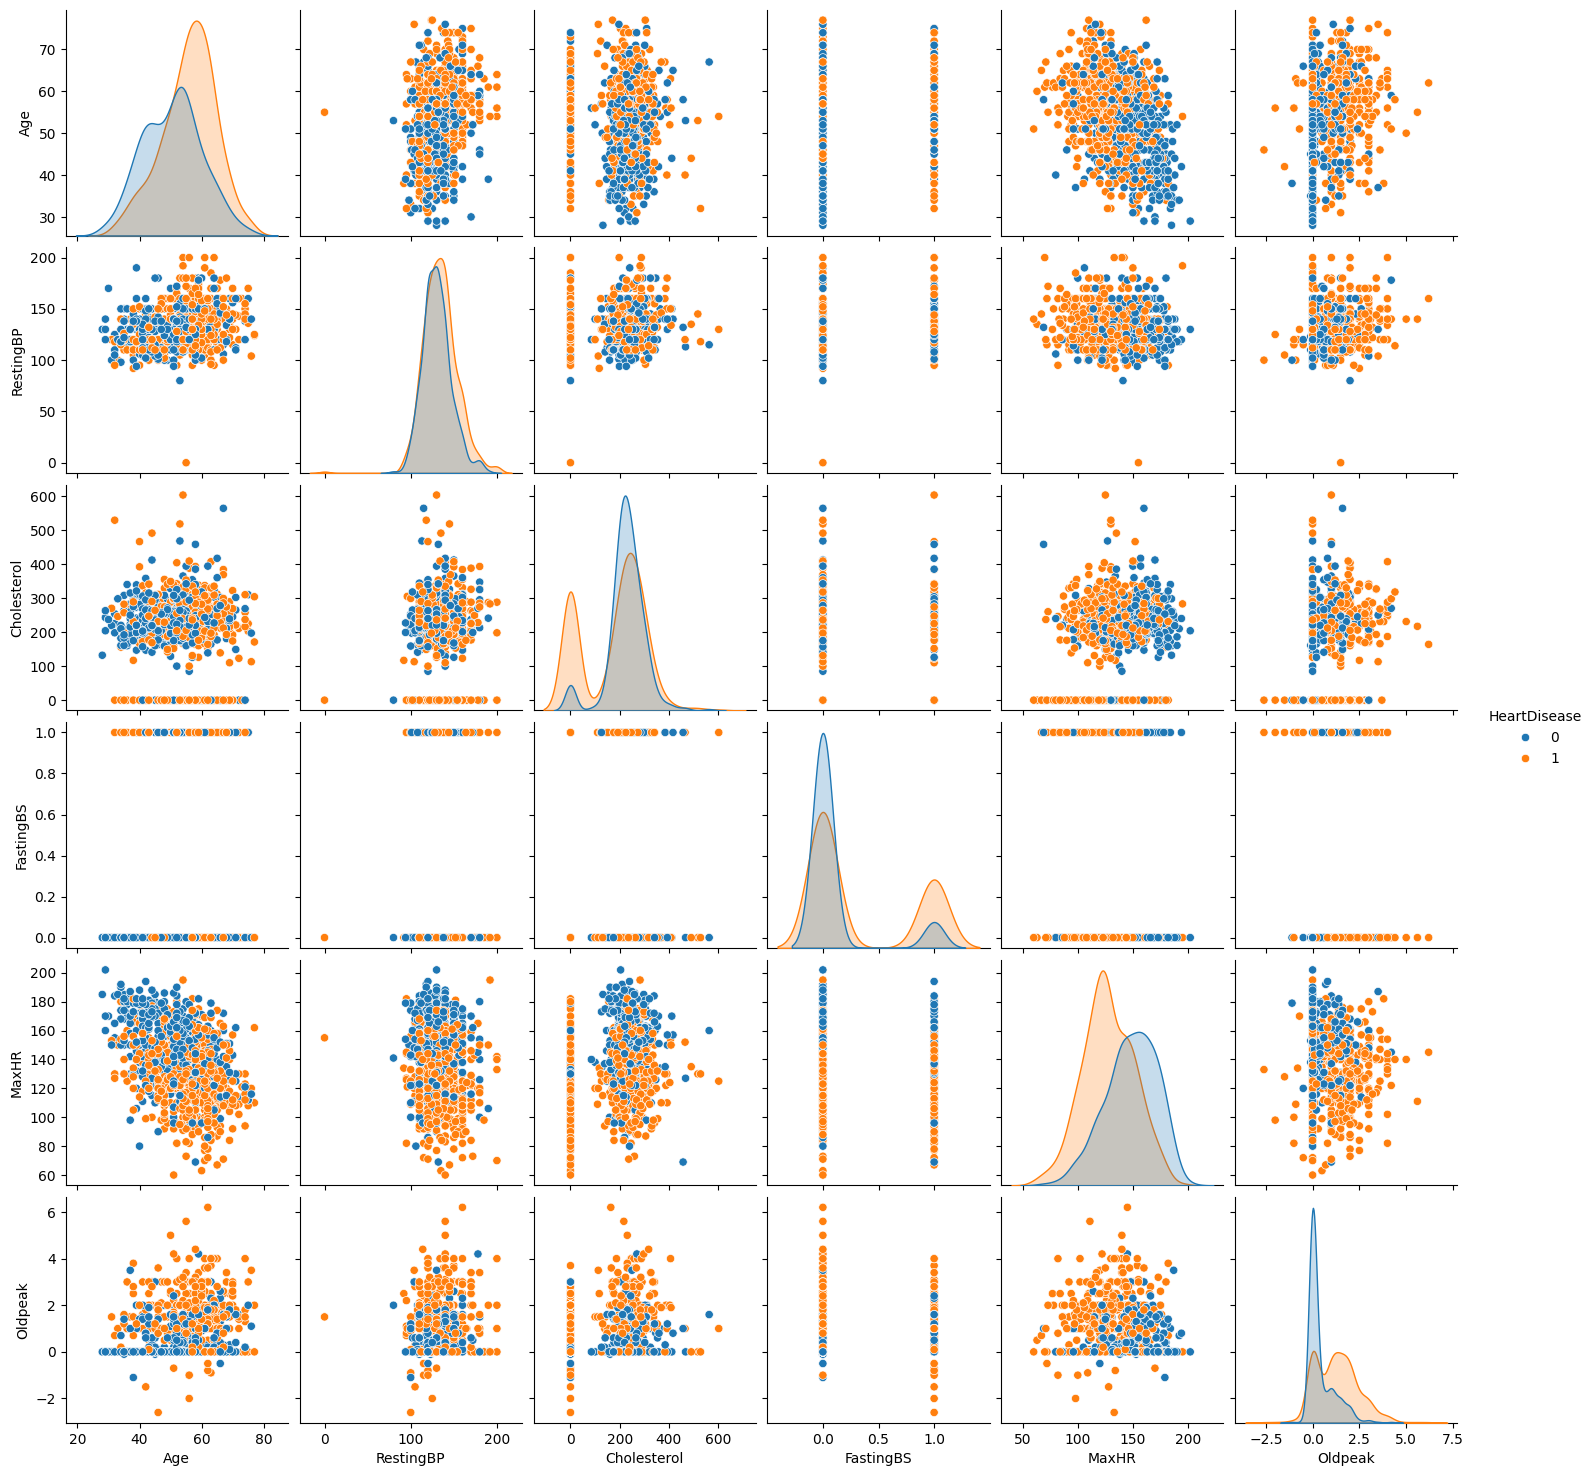

In [18]:
sns.pairplot(df, hue="HeartDisease")

The pairplot visualization provides insight into relationships between numerical variables and the target variable.

It shows that patients with heart disease tend to be older and have lower maximum heart rate during exercise.

Higher values of Oldpeak are also more common among patients with heart disease.

These patterns suggest that exercise-related measurements and age are important indicators for predicting heart disease.

Feature Engineering Suggestions

To improve predictive models, the following steps can be applied.

Encode Categorical Variables

In [25]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,"AgeGroup_(40, 60]","AgeGroup_(60, 80]"
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True,False,False
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True,False,False
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True,True,False


Сategorical variables were encoded using one-hot encoding. This converts text categories (such as gender or chest pain type) into numerical values so that machine learning algorithms can process them.

Feature Scaling

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)
scaled_df = pd.DataFrame(scaled_data, columns=df_encoded.columns)

scaled_df.head()


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,"AgeGroup_(40, 60]","AgeGroup_(60, 80]"
0,-1.433140,0.410909,0.825070,-0.551341,1.382928,-0.832432,-1.113115,0.515952,2.075177,-0.532838,-0.229679,0.814275,-0.490449,-0.823556,-1.002181,1.150674,-1.386927,-0.563093
1,-0.478484,1.491752,-0.171961,-0.551341,0.754157,0.105664,0.898380,-1.938163,-0.481887,1.876744,-0.229679,0.814275,-0.490449,-0.823556,0.997824,-0.869056,0.721018,-0.563093
2,-1.751359,-0.129513,0.770188,-0.551341,-1.525138,-0.832432,-1.113115,0.515952,2.075177,-0.532838,-0.229679,-1.228087,2.038947,-0.823556,-1.002181,1.150674,-1.386927,-0.563093
3,-0.584556,0.302825,0.139040,-0.551341,-1.132156,0.574711,0.898380,-1.938163,-0.481887,-0.532838,-0.229679,0.814275,-0.490449,1.214246,0.997824,-0.869056,0.721018,-0.563093
4,0.051881,0.951331,-0.034755,-0.551341,-0.581981,-0.832432,-1.113115,0.515952,-0.481887,1.876744,-0.229679,0.814275,-0.490449,-0.823556,-1.002181,1.150674,0.721018,-0.563093


Numerical variables can be standardized using StandardScaler. Standardization puts features on a similar scale, which helps some algorithms perform better because they are sensitive to large differences in variable ranges.

Create Age Groups

In [27]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[20,40,60,80])
df["AgeGroup"].value_counts()

AgeGroup
(40, 60]    604
(60, 80]    221
(20, 40]     93
Name: count, dtype: int64

This can capture age-related risk patterns.

Key Findings

Main observations from the analysis:

- Age is an important factor in heart disease risk.
- Male patients show higher prevalence of heart disease.
- Exercise-related variables (ExerciseAngina, MaxHR, Oldpeak) are strong indicators.
- Chest pain type carries significant predictive information.
- Some variables contain potential outliers or unrealistic values.

Conclusion

The Heart Failure Prediction dataset provides valuable clinical indicators for predicting cardiovascular disease.

Exploratory data analysis shows that demographic variables, exercise test results, and chest pain characteristics strongly relate to heart disease outcomes.

Before building machine learning models, important preprocessing steps include:

- Encoding categorical variables
- Handling outliers
- Scaling numerical features
- Possibly treating zero cholesterol values as missing data

With proper preprocessing and feature engineering, this dataset can be used to build accurate predictive models for heart disease risk.